# Parameter estimation results

This notebook inspects the results from the various parameter estimation runs.


---

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import corner
import sys


def summary_stats(data_file):
    data = az.from_netcdf(data_file)
    summary_df = az.summary(data)
    print(summary_df)


def gw_posterior_plot(data_file):
    data = az.from_netcdf(data_file)

    samples = np.column_stack([
        data.posterior['ha'].values.flatten()
    ])

    print("Mean of selected parameters:")
    print(data.posterior['ha'].mean())

    # Transform to log space
    log_samples = np.log10(samples)

    # Set plot limits (adjust these values based on your data)
    ranges = [
        (-18, -4),  # ha limits
    ]


    # Create corner plot
    fig = corner.corner(
        log_samples,
        labels=['log(ha)'],
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        range=ranges,
        bins=30,  # Adjust number of bins as needed
        smooth=1.0,  # Adjust smoothing as needed
        plot_datapoints=True,
        fill_contours=True,
        levels=[0.68, 0.95]  # 1 and 2 sigma contours
    )

    plt.tight_layout()
    plt.show()



# def efac_corner_plot(data_file):
#     data = az.from_netcdf(data_file)

#     efac_samples = data.posterior['EFAC'].values

#     # Select first 3 EFAC components
#     selected_efac_samples = np.column_stack([
#         efac_samples[..., 0].flatten(),
#         efac_samples[..., 1].flatten(),
#         efac_samples[..., 2].flatten()
#     ])

#     # Create corner plot for EFAC parameters
#     fig = corner.corner(
#         selected_efac_samples,
#         labels=['EFAC_0', 'EFAC_1', 'EFAC_2'],
#         quantiles=[0.16, 0.5, 0.84],
#         show_titles=True,
#         title_kwargs={"fontsize": 12},
#         bins=30,
#         smooth=1.0,
#         plot_datapoints=True,
#         fill_contours=True,
#         levels=[0.68, 0.95],  # 1 and 2 sigma contours
#         range=[(0.5, 2.0), (0.5, 2.0), (0.5, 2.0)]  # Set axis limits for all three parameters
#     )

#     plt.tight_layout()
#     plt.show()



# def pulsar_noise_corner_plot(data_file):
#     data = az.from_netcdf(data_file)

#     pulsar_noise_samples = data.posterior['σp'].values

#     # Transform to log space
#     pulsar_noise_samples = np.log10(pulsar_noise_samples)

#     # Set plot limits (adjust these values based on your data)
#     ranges = [
#         (-18, -12),  
#     ]


#     # Select first 5 pulsar noise components
#     selected_efac_samples = np.column_stack([
#         pulsar_noise_samples[..., 0].flatten(),
#         pulsar_noise_samples[..., 1].flatten(),
#         pulsar_noise_samples[..., 2].flatten(),
#         pulsar_noise_samples[..., 3].flatten(),
#         pulsar_noise_samples[..., 4].flatten()
#     ])

#     # Create corner plot for pulsar noise parameters
#     fig = corner.corner(
#         pulsar_noise_samples,
#         labels=['σp_0', 'σp_1', 'σp_2', 'σp_3', 'σp_4'],
#         quantiles=[0.16, 0.5, 0.84],
#         show_titles=True,
#         range=ranges,
#         title_kwargs={"fontsize": 12},
#     )
    


Mean of selected parameters:
<xarray.DataArray 'ha' ()> Size: 8B
array(1.05224557e-05)


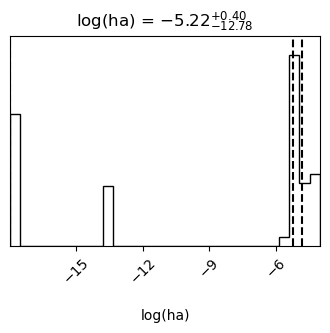

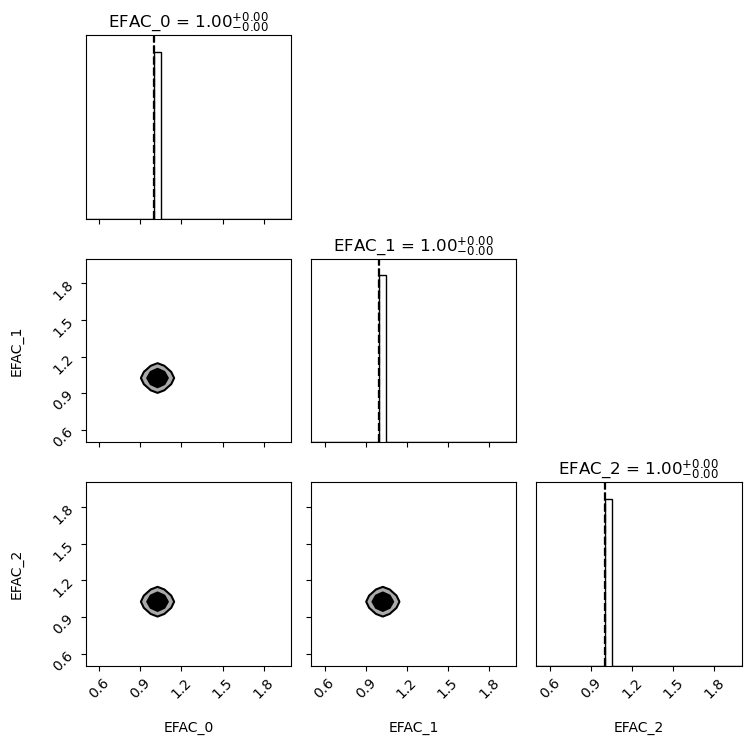

In [5]:
data_file = '../sandbox/outputs/mdc1_parameter_estimation_results_2025-04-24_08-47-56.nc'
#summary_stats(data_file)
gw_posterior_plot(data_file)
efac_corner_plot(data_file)

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


          mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
EFAC[0]  1.133  0.0   1.133    1.133        0.0      0.0    1000.0    1000.0   
EFAC[1]  1.260  0.0   1.260    1.260        0.0      0.0    1000.0    1000.0   
EFAC[2]  1.350  0.0   1.350    1.350        0.0      0.0    1000.0    1000.0   
EFAC[3]  0.903  0.0   0.903    0.903        0.0      0.0    1000.0    1000.0   
EFAC[4]  1.069  0.0   1.069    1.069        0.0      0.0    1000.0    1000.0   
...        ...  ...     ...      ...        ...      ...       ...       ...   
σp[27]   0.000  0.0   0.000    0.000        0.0      0.0    1000.0    1000.0   
σp[28]   0.000  0.0   0.000    0.000        0.0      0.0    1000.0    1000.0   
σp[29]   0.000  0.0   0.000    0.000        0.0      0.0    1000.0    1000.0   
σp[30]   0.000  0.0   0.000    0.000        0.0      0.0    1000.0    1000.0   
σp[31]   0.000  0.0   0.000    0.000        0.0      0.0    1000.0    1000.0   

         r_hat  
EFAC[0]    NaN  
EFAC[

/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/corner/core.py:928: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  return ax.set_ylim(new_ylim)


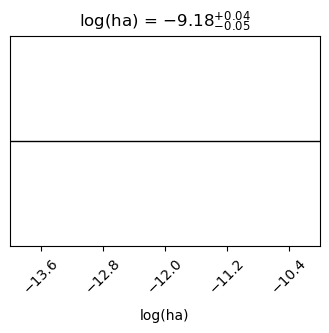

In [6]:

data_file = '../sandbox/outputs/test_parameter_estimation_results_2025-04-22_16-23-06.nc'
summary_stats(data_file)
gw_posterior_plot(data_file)


# Diagnostics 

In [6]:
# import arviz as az
# import matplotlib.pyplot as plt
# import pandas as pd
# import os # For checking if file exists

# # --- Configuration ---
# # Replace with the actual path to your saved NetCDF file
# # It's good practice to construct the path safely
# output_dir = "outputs"
# # You might need to get the correct timestamp or find the latest file
# # For demonstration, let's assume a specific timestamp exists or you know the name
# # Example: Replace 'YYYYMMDD_HHMMSS' with the actual timestamp from your filename
# timestamp = "YYYYMMDD_HHMMSS" # <-- *** REPLACE THIS ***
# fname = os.path.join(output_dir, f"mdc1_parameter_estimation_results_{timestamp}.nc")

# # Set display options for potentially wide summary tables
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', 1000)

# # --- Check if file exists ---
# if not os.path.exists(fname):
#     print(f"Error: File not found at '{fname}'")
#     print("Please ensure the path and timestamp are correct.")
#     # Exit or raise error if file isn't found
#     exit() # Or raise FileNotFoundError(f"File not found: {fname}")





def diagnostics(fname):
    inf_data = az.from_netcdf(fname)
    print(f"Successfully loaded InferenceData from: {fname}")


    # --- 1. Get Full Summary ---
    print("\n--- Calculating Full MCMC Summary ---")
    # Calculate summary for ALL variables first
    full_summary_df = az.summary(inf_data, kind='all', round_to=3, hdi_prob=0.94) # Using default HDI

    print(full_summary_df['sd'])



    # --- 2. Filter out Constant Deterministic Variables ---
    # Identify variables with near-zero standard deviation (likely constants)
    # Use a small tolerance instead of exact zero for floating point comparisons
    tolerance = 1e-12
    is_sampled_or_derived = full_summary_df['sd'] > tolerance
    sampled_summary_df = full_summary_df[is_sampled_or_derived]

    print("\n--- Filtered MCMC Summary (Excluding Constant Deterministics) ---")
    if sampled_summary_df.empty:
        print("Warning: No variables with standard deviation > tolerance found. Check model or tolerance.")
    else:
        print(sampled_summary_df)

    # --- 3. Diagnostics on Filtered Parameters ---
    if not sampled_summary_df.empty:
        print("\n--- Interpretation Guidance (Filtered Parameters) ---")
        print("Checking R-hat and ESS only for variables that showed variation:")
        # Check R-hat
        max_rhat = sampled_summary_df['r_hat'].max()
        print(f"\nMaximum R-hat value (filtered): {max_rhat:.3f}")
        if max_rhat > 1.05:
            print("WARNING: Maximum R-hat is high (> 1.05), suggesting potential convergence issues. Consider increasing 'num_warmup'.")
        elif max_rhat > 1.01:
            print("NOTE: Maximum R-hat is slightly elevated (> 1.01). Check trace plots carefully.")
        else:
            print("R-hat values look good (<= 1.01).")

        # Check ESS
        min_ess_bulk = sampled_summary_df['ess_bulk'].min()
        min_ess_tail = sampled_summary_df['ess_tail'].min()
        print(f"Minimum Bulk ESS (filtered): {min_ess_bulk:.0f}")
        print(f"Minimum Tail ESS (filtered): {min_ess_tail:.0f}")
        if min_ess_bulk < 400 or min_ess_tail < 400:
            print("WARNING: Minimum ESS is low (< 400). Consider increasing 'num_samples'.")
        else:
            print("ESS values look sufficient (>= 400).")

        # --- 4. Trace Plots for Filtered Parameters ---
        print("\n--- Generating Trace Plots (Filtered Parameters) ---")
        # Get the names of the variables to plot from the filtered summary index
        var_names_to_plot = sampled_summary_df.index.tolist()

        if var_names_to_plot:
            try:
                trace_plot = az.plot_trace(inf_data, var_names=var_names_to_plot, compact=True)
                plt.tight_layout()
                print("Displaying trace plots...")
                plt.show()
            except Exception as e:
                print(f"Could not generate trace plots: {e}")
        else:
            print("No variables left to plot after filtering.")

        print("\n--- Trace Plot Interpretation ---")
        print("(Interpret as before, focusing on these non-constant variables)")

    else:
        print("\nSkipping detailed diagnostics as no non-constant parameters were found in the summary.")


    # --- 5. Divergent Transitions (Applies to the whole sampler run) ---
    # This check remains the same as it reflects the sampler's overall behavior
    print("\n--- Checking for Divergent Transitions ---")
    if "sample_stats" in inf_data and "diverging" in inf_data.sample_stats:
        # ... (rest of divergence check code is identical to previous version) ...
        divergences = inf_data.sample_stats["diverging"].sum().item() # .item() gets scalar value
        total_samples = inf_data.posterior.dims["chain"] * inf_data.posterior.dims["draw"]
        print(f"Total number of divergent transitions: {divergences}")
        print(f"Total post-warmup samples: {total_samples}")
        if divergences > 0:
            divergence_rate = (divergences / total_samples) * 100
            print(f"Divergence rate: {divergence_rate:.2f}%")
            print("WARNING: Divergences indicate potential issues exploring the posterior.")
            print("Consider:")
            print("  1. Model Reparameterization (e.g., non-centered parameterization).")
            print("  2. Increasing 'target_accept_prob' in the NUTS kernel (e.g., kernel = NUTS(model, target_accept_prob=0.90 or 0.95)).")
            print("  3. Using stronger priors if appropriate.")
        else:
            print("No divergent transitions found. Good!")
    else:
        print("Divergence information not found in sample_stats.")


    print("\n--- Diagnostics Complete ---")


In [7]:
fname = '../sandbox/outputs/mdc1_parameter_estimation_results_2025-04-24_08-47-56.nc'
diagnostics(fname)

Successfully loaded InferenceData from: ../sandbox/outputs/mdc1_parameter_estimation_results_2025-04-24_08-47-56.nc

--- Calculating Full MCMC Summary ---


/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/fred/oz022/tkimpson/conda_envs/Argus/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


EFAC[0]    0.0
EFAC[1]    0.0
EFAC[2]    0.0
EFAC[3]    0.0
EFAC[4]    0.0
          ... 
σp[30]     0.0
σp[31]     0.0
σp[32]     0.0
σp[33]     0.0
σp[34]     0.0
Name: sd, Length: 142, dtype: float64

--- Filtered MCMC Summary (Excluding Constant Deterministics) ---

Skipping detailed diagnostics as no non-constant parameters were found in the summary.

--- Checking for Divergent Transitions ---
Total number of divergent transitions: 1457
Total post-warmup samples: 4000
Divergence rate: 36.43%
Consider:
  1. Model Reparameterization (e.g., non-centered parameterization).
  2. Increasing 'target_accept_prob' in the NUTS kernel (e.g., kernel = NUTS(model, target_accept_prob=0.90 or 0.95)).
  3. Using stronger priors if appropriate.

--- Diagnostics Complete ---


/tmp/ipykernel_3607824/12183183.py:111: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_samples = inf_data.posterior.dims["chain"] * inf_data.posterior.dims["draw"]


In [7]:
data = az.from_netcdf(data_file)

samples = np.column_stack([
    data.posterior['ha'].values.flatten()
])

print("Mean of selected parameters:")
print(data.posterior['ha'].mean())

# Transform to log space
log_samples = np.log10(samples)

# Set plot limits (adjust these values based on your data)
ranges = [
    (-14, -10),  # ha limits
]

Mean of selected parameters:
<xarray.DataArray 'ha' ()> Size: 8B
array(6.58847656e-10)


In [16]:
y = data.posterior['ha'].values

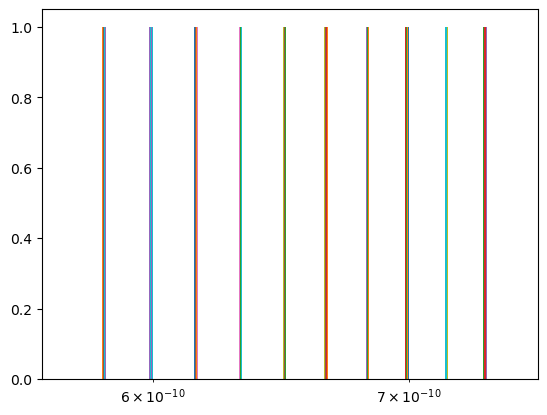

In [18]:
plt.hist(y)
plt.xscale('log')

In [19]:
y 

array([[7.48162088e-10, 7.48096325e-10, 7.48033874e-10, 7.47971098e-10,
        7.47711462e-10, 7.47650463e-10, 7.47585982e-10, 7.47521498e-10,
        7.47459802e-10, 7.47395915e-10, 7.47335489e-10, 7.47273153e-10,
        7.47208626e-10, 7.47140048e-10, 7.46890490e-10, 7.46822728e-10,
        7.46758444e-10, 7.46697363e-10, 7.46638001e-10, 7.46573692e-10,
        7.46311683e-10, 7.46247727e-10, 7.46182559e-10, 7.46124139e-10,
        7.46061688e-10, 7.45026134e-10, 7.45026134e-10, 7.44962290e-10,
        7.44896119e-10, 7.44830705e-10, 7.44760579e-10, 7.44694109e-10,
        7.44631708e-10, 7.44571348e-10, 7.44507212e-10, 7.43907325e-10,
        7.43836836e-10, 7.43570856e-10, 7.43305826e-10, 7.43305826e-10,
        7.42247768e-10, 7.42182170e-10, 7.42129652e-10, 7.42062045e-10,
        7.41997264e-10, 7.41930144e-10, 7.41868427e-10, 7.41806014e-10,
        7.41743336e-10, 7.41116574e-10, 7.40849397e-10, 7.40584297e-10,
        7.40584297e-10, 7.40516350e-10, 7.40451605e-10, 7.403864